# Matching a Load Path on a Surrogate

**The problem.** Find a design whose load path matches a target curve. The target is the
`[100, 100, 100, 100]` arch's path — chosen because a design reaching objective **zero** then
provably exists, which is what makes a comparison between optimisers fair. Recovering those
radii is not the goal; matching the curve is.

**Why a surrogate.** In
[`ArcLengthControlledShapeDesign.ipynb`](ArcLengthControlledShapeDesign.ipynb) §5 the solver's
adaptive arc stepping makes the objective discontinuous, and SLSQP stops at `3.334e-03` after
**118 solves**. ADAM, which never reads the objective value, reaches `4.097e-04` in 27.
[`SurrogateBasedShapeDesign.ipynb`](SurrogateBasedShapeDesign.ipynb) fits the *simulation
output* — load factor and displacement over shape **and arc length** — and stops short of
optimising. This closes that loop.

**Why the discontinuity goes.** Objective B has two design-dependent parts, and evaluating
fitted responses at a **fixed** set of arc lengths removes both:

- the arc-step count changes with the design, moving the sample points;
- B's own mask, `sT[1:] <= s[-1]`, changes the sample *count*, because how far a design traces
  depends on the design.

**What is at risk.** Twenty curves is thin cover for four dimensions over `[80,120]⁴`. A smooth
objective converges cleanly whether or not it is right, so §3 measures the fit before §4 trusts
it, and §5 solves what SLSQP finds rather than quoting the surrogate on itself.

> Needs `ge_rbf`: `uv sync --extra surrogate`. **About 30 minutes**, nearly all of it
> arc-length solves — still a fraction of SLSQP's 118. Committed with its output.

In [1]:
import contextlib
import logging
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.stats import qmc
from sklearn.model_selection import GroupKFold

from fem2d.meshers import Q8Mesh
from fem2d.solvers import ArcLengthSolver
from fem2d.surrogate import PathSurrogate

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)

## The problem, transcribed

Unchanged from [`ArcLengthControlledShapeDesign.ipynb`](ArcLengthControlledShapeDesign.ipynb):
the 270° arch on four radii, the paper's `[80,120]⁴` box, and objective **B**. The `Objective`
class is the **yardstick, not the thing optimised** — it produces the target path, and says what
SLSQP actually found.

In [2]:
h = 12**0.5
E = 210000.0                   # 210 GPa, in N and mm
v, t, plane = 0.3, 1.0, 0      # plane stress: a beam of unit width
R = 100.0                      # base radius, held at the two ends
Span = 270.0                   # the paper's arch, -45 to 225 degrees
Load = -1.0

ObjElNum, ObjArc, ObjTotal = 20, 200.0, 2600.0

Box = [(80.0, 120.0)]*4                                    # the paper's design box
Lower = np.array([b[0] for b in Box])
Upper = np.array([b[1] for b in Box])
Start = np.random.default_rng(0).uniform(80.0, 120.0, 4)   # where SLSQP and ADAM began


def Arch(radii):
    m = Q8Mesh(E, v, t, plane, 'Q8')
    m.SemiCircularArch(ObjElNum, R, [float(r) for r in np.atleast_1d(radii)], h, Load, Span=Span)
    return m


def Curve(radii, Sensitivity=True):
    """One design's load path, parametrised by accumulated arc length."""
    m = Arch(radii)
    with quiet():
        ArcLengthSolver(m, ArcLength=ObjArc, TotalArcLength=ObjTotal,
                        tol=1e-6, MaxIter=9, Sensitivity=Sensitivity).Solve()

    s, u, lam = m.ArcValues, m.AllU[m.LoadNode, :], np.ravel(m.LoadValues)
    if not Sensitivity:
        return dict(s=s, u=u, lam=lam)

    # Row 0 is the undeformed state: no design variable moves it and the solver records no
    # tangent there, so the derivative arrays are one shorter than the path.
    Zero = np.zeros((1, m.VariableNumber))
    return dict(s=s, u=u, lam=lam,
                dLamdx=np.vstack((Zero, np.atleast_2d(m.dLdx))),
                dUdx=np.vstack((Zero, np.atleast_3d(m.dUdx_All)[m.LoadNode, :, :].T)),
                dLamds=np.concatenate(([0.0], np.ravel(m.dLds))),
                dUds=np.concatenate(([0.0], m.dUds_All[m.LoadNode, :])))

In [3]:
def Interp(s, y, dy, At):
    """Linear interpolation of y(s) onto At, and of dy/dx through the same weights."""
    k = np.clip(np.searchsorted(s, At, side='right') - 1, 0, len(s) - 2)
    w = (At - s[k])/(s[k+1] - s[k])
    Grad = None if dy is None else (1 - w)[:, None]*dy[k] + w[:, None]*dy[k+1]
    return (1 - w)*y[k] + w*y[k+1], Grad


class Objective:
    """Objective B of the paper. The yardstick, not the thing optimised."""

    def __init__(self, TargetRadii):
        Target = Curve(TargetRadii, Sensitivity=False)
        self.sT, self.uT, self.lamT = Target['s'], Target['u'], Target['lam']
        # Load and displacement differ in magnitude; scaling both by the target range makes
        # them weigh equally.
        self.ScaleLam, self.ScaleU = np.ptp(self.lamT), np.ptp(self.uT)
        self.Steps = len(self.sT) - 1

    def _MSE(self, ResLam, ResU, dLam, dU):
        # Residuals arrive already divided by the scale; the sensitivities do not, so the
        # gradient divides a second time.
        N = len(ResLam)
        f = np.mean(ResLam**2) + np.mean(ResU**2)
        if dLam is None:
            return f, None
        return f, -2*(ResLam @ dLam/self.ScaleLam + ResU @ dU/self.ScaleU)/N

    def From(self, Path):
        """Objective B from a path already solved, so nothing is solved twice."""
        s, u, lam = Path['s'], Path['u'], Path['lam']
        dLam, dU = Path.get('dLamdx'), Path.get('dUdx')
        self.Steps = len(s) - 1

        KeepB = self.sT[1:] <= s[-1]
        AtB = self.sT[1:][KeepB]
        LamD, dLamD = Interp(s, lam, dLam, AtB)
        UD, dUD = Interp(s, u, dU, AtB)
        return self._MSE((self.lamT[1:][KeepB] - LamD)/self.ScaleLam,
                         (self.uT[1:][KeepB] - UD)/self.ScaleU, dLamD, dUD)

    def __call__(self, radii, Sensitivity=True):
        return self.From(Curve(radii, Sensitivity))


Clock = time.perf_counter()
MSE = Objective([R]*4)
print(f'target: {MSE.Steps} steps, arc length {MSE.sT[-1]:.1f}, {time.perf_counter()-Clock:.0f}s')
print(f'        load factor range {MSE.ScaleLam:.1f}, displacement range {MSE.ScaleU:.2f}')

target: 17 steps, arc length 2619.2, 11s
        load factor range 295.2, displacement range 212.34


## 1. Twenty curves

Latin hypercube over `[80,120]⁴`, oversized, because two kinds of design have to be discarded.

- **Untraceable** — roughly one in eight runs into a limit point the solver cannot pass.
- **Collapsed** — the design snaps through and sheds its load. Three of the first twenty here
  reach load factors of −1365, −2492 and **−4128**, against a target spanning −15 to 280.

The second is the one that matters, and it is not a numerical nuisance. Such a design says
nothing about matching a target the arch never approaches, and its gradients run 30× the median,
so in a gradient-enhanced least-squares fit it dominates everything else. Keeping them makes the
cross-validation error **26%** instead of 6% and leaves the surrogate rating designs above a
perfect match. They are treated like an untraceable design: solved, counted, left out of the fit.

The rule is stated without reference to the answer — the path must stay within two target-ranges
of the target's own band — so it needs only the target, which is known before anything is
sampled. The cost is that the surrogate is then blind to the collapsing region; the box bounds
on SLSQP and the verification solve are what contain that.

Each solve carries sensitivities and contributes **one row per arc step**, not one row.

In [4]:
Wanted = 20
Band = 2.0                                  # target-ranges of slack before a path is collapsed
Low, High = MSE.lamT.min() - Band*MSE.ScaleLam, MSE.lamT.max() + Band*MSE.ScaleLam
Draw = qmc.LatinHypercube(d=4, seed=1).random(32)*(Upper - Lower) + Lower

Paths, Untraceable, Collapsed = [], [], []
Clock = time.perf_counter()
for Radii in Draw:
    if len(Paths) == Wanted:
        break
    try:
        Path = Curve(Radii)
    except RuntimeError:
        Untraceable.append(Radii)
        continue
    if Path['lam'].min() < Low or Path['lam'].max() > High:
        Collapsed.append((Radii, Path['lam'].min()))
        continue
    Paths.append((Radii, Path))
Elapsed = time.perf_counter() - Clock

Solves = len(Paths) + len(Untraceable) + len(Collapsed)
print(f'{Solves} solves: {len(Paths)} usable, {len(Untraceable)} untraceable, '
      f'{len(Collapsed)} collapsed, {Elapsed/60:.1f} min')
for Radii, Bottom in Collapsed:
    print(f'   collapsed to lambda {Bottom:>9.0f} at '
          f'{np.array2string(Radii, precision=1, floatmode="fixed")}')

# Groups say which curve each row came from: the scaler measures trajectory spacing with them
# and the centre-count search holds whole curves out.
X = np.concatenate([np.repeat(r[None, :], P['s'].size - 1, axis=0) for r, P in Paths])
S = np.concatenate([P['s'][1:] for _, P in Paths])
Groups = np.concatenate([np.full(P['s'].size - 1, i) for i, (_, P) in enumerate(Paths)])
Lam = np.concatenate([P['lam'][1:] for _, P in Paths])
dLamdx = np.concatenate([P['dLamdx'][1:] for _, P in Paths])
dLamds = np.concatenate([P['dLamds'][1:] for _, P in Paths])
U = np.concatenate([P['u'][1:] for _, P in Paths])
dUdx = np.concatenate([P['dUdx'][1:] for _, P in Paths])
dUds = np.concatenate([P['dUds'][1:] for _, P in Paths])
Reach = min(P['s'][-1] for _, P in Paths)

print(f'{X.shape[0]} sample rows over {X.shape[1] + 1} inputs')
print(f'load factor {Lam.min():.0f} to {Lam.max():.0f}, against the target\'s '
      f'{MSE.lamT.min():.0f} to {MSE.lamT.max():.0f}')
print(f'every curve covers arc length 0 to {Reach:.0f}; the target reaches {MSE.sT[-1]:.0f}')

22 solves: 20 usable, 0 untraceable, 2 collapsed, 11.6 min
   collapsed to lambda     -1247 at [102.3  88.8 113.1  91.1]
   collapsed to lambda     -1296 at [ 98.6  84.0 117.9  80.3]
356 sample rows over 5 inputs
load factor -138 to 859, against the target's -15 to 280
every curve covers arc length 0 to 2603; the target reaches 2619


## 2. Two surrogates, and the objective on them

`ge_rbf` does the fitting: `TrajectoryScaler` for the arc-length axis, `IsotropicTransformer`
for the frame, `basis_search` for the centre count and shape parameter. Then objective B is
assembled from the fitted responses, with the arc lengths computed **once** in `__init__` —
`At`, `LamT` and `UT` are fixed arrays, so neither the sample count nor the sample locations can
move with the design. That is the whole mechanism.

In [5]:
class SurrogateObjective:
    """Objective B on two fitted responses. Cheap, smooth, and only as good as the fit."""

    def __init__(self, LamModel, UModel, Truth, Reach):
        self.LamModel, self.UModel = LamModel, UModel
        self.ScaleLam, self.ScaleU = Truth.ScaleLam, Truth.ScaleU
        Keep = Truth.sT[1:] <= Reach                 # applied once, never reconsidered
        self.At = Truth.sT[1:][Keep]
        self.LamT, self.UT = Truth.lamT[1:][Keep], Truth.uT[1:][Keep]

    def __call__(self, x, Gradient=True):
        x = np.atleast_2d(np.asarray(x, dtype=float))
        LamHat, dLamdx, _ = self.LamModel.Predict(x, self.At, Gradient=True)
        UHat, dUdx, _ = self.UModel.Predict(x, self.At, Gradient=True)

        ResLam = (self.LamT - LamHat)/self.ScaleLam
        ResU = (self.UT - UHat)/self.ScaleU
        f = float(np.mean(ResLam**2) + np.mean(ResU**2))
        if not Gradient:
            return f
        N = ResLam.size
        return f, -2*(ResLam @ dLamdx/self.ScaleLam + ResU @ dUdx/self.ScaleU)/N

    def Value(self, x):
        return self(x, Gradient=False)

    def Grad(self, x):
        return self(x)[1]


Clock = time.perf_counter()
LamModel = PathSurrogate().Fit(X, S, Lam, dLamdx, dLamds, Groups=Groups)
UModel = PathSurrogate().Fit(X, S, U, dUdx, dUds, Groups=Groups)
Surrogate = SurrogateObjective(LamModel, UModel, MSE, Reach)
print(f'fitted in {time.perf_counter() - Clock:.0f}s, no further solves')
print()
for Name, Model in (('load factor', LamModel), ('displacement', UModel)):
    print(f'{Name:<14} {Model.Frame_.method_:<8} {Model.Model_.centers_.shape[0]:>3} centres  '
          f'epsilon {Model.Search_.best_epsilon:.4g}  condition {Model.Model_.condition_:.2e}')
print(f'objective uses {Surrogate.At.size} of {MSE.sT.size - 1} target points')

fitted in 32s, no further solves

load factor    ge-lhm   178 centres  epsilon 0.0006901  condition 1.33e+06
displacement   ge-lhm    68 centres  epsilon 0.002554  condition 2.44e+05
objective uses 16 of 17 target points


## 3. Is it smooth, and is it right?

Two different questions.

- **Smooth** — the gradient against central differences with the step swept. The same check in
  the original notebook has to report which arc-step counts it straddled; here there is nothing
  to flag.
- **Right** — 5-fold grouped cross-validation, holding out four whole curves at a time, plus the
  four designs whose true objective is known. The target attains **B = 0** and is therefore the
  unique global minimum, so a surrogate rating anything below its own value there is claiming
  something beats a perfect match. That would prove the landscape wrong.

In [6]:
Counts = sorted({int(np.count_nonzero(MSE.sT[1:] <= P['s'][-1])) for _, P in Paths})
print(f'true objective B would use {Counts} target points across the {len(Paths)} curves;')
print(f'the surrogate objective uses {Surrogate.At.size} at every design, by construction')
print()

Probe = np.array([100.0, 105.0, 98.0, 102.0])
Value, Grad = Surrogate(Probe)
print(f'at {Probe}: f = {Value:.6e}')
print(f"{'step':>10}{'worst relative error':>24}")
Best = np.inf
for Step in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    Difference = np.empty(4)
    for i in range(4):
        Plus, Minus = np.copy(Probe), np.copy(Probe)
        Plus[i] += Step
        Minus[i] -= Step
        Difference[i] = (Surrogate.Value(Plus) - Surrogate.Value(Minus))/(2*Step)
    Error = np.max(np.abs(Difference - Grad)/np.maximum(np.abs(Grad), 1e-30))
    Best = min(Best, Error)
    print(f'{Step:>10.0e}{Error:>24.2e}')
print(f'best {Best:.2e}, and no arc-step count to flag')

true objective B would use [16, 17] target points across the 20 curves;
the surrogate objective uses 16 at every design, by construction

at [100. 105.  98. 102.]: f = 6.291390e-03
      step    worst relative error
     1e-01                2.47e-05
     1e-02                2.55e-07
     1e-03                4.44e-07
     1e-04                4.36e-06
     1e-05                7.75e-06
     1e-06                2.91e-04
best 2.55e-07, and no arc-step count to flag


In [7]:
Clock = time.perf_counter()
LamErrs, UErrs = [], []
for Train, Test in GroupKFold(n_splits=5).split(X, Lam, groups=Groups):
    Test = Test[S[Test] <= Reach]
    Fold = PathSurrogate().Fit(X[Train], S[Train], Lam[Train], dLamdx[Train], dLamds[Train],
                               Groups=Groups[Train])
    FoldU = PathSurrogate().Fit(X[Train], S[Train], U[Train], dUdx[Train], dUds[Train],
                                Groups=Groups[Train])
    LamErrs.append(np.max(np.abs(Fold.Predict(X[Test], S[Test]) - Lam[Test]))/np.ptp(Lam))
    UErrs.append(np.max(np.abs(FoldU.Predict(X[Test], S[Test]) - U[Test]))/np.ptp(U))

print(f'5-fold grouped cross-validation, {(time.perf_counter() - Clock)/60:.1f} min')
print(f'   load factor   median {np.median(LamErrs):.1%}, worst {np.max(LamErrs):.1%}')
print(f'   displacement  median {np.median(UErrs):.1%}, worst {np.max(UErrs):.1%}')
print()

Known = [('target [100]*4', np.full(4, R), 0.0),
         ('ADAM', np.array([95.033, 99.359, 94.361, 97.712]), 4.097e-04),
         ('SLSQP', np.array([102.295, 106.621, 89.306, 89.519]), 3.334e-03),
         ('start', Start, 1.431e-01)]

print(f"{'design':<16}{'true B':>12}{'surrogate':>12}   (listed by increasing true B)")
for Name, Radii, Value in Known:
    print(f'{Name:<16}{Value:>12.3e}{Surrogate.Value(Radii):>12.3e}')
print()
print('the value at the target is the floor: the objective cannot resolve below its own')
print('fitting error, however smooth it is.')

5-fold grouped cross-validation, 1.8 min
   load factor   median 4.4%, worst 7.2%
   displacement  median 2.7%, worst 3.1%

design                true B   surrogate   (listed by increasing true B)
target [100]*4     0.000e+00   3.186e-04
ADAM               4.097e-04   6.654e-04
SLSQP              3.334e-03   4.524e-03
start              1.431e-01   1.547e-01

the value at the target is the floor: the objective cannot resolve below its own
fitting error, however smooth it is.


## 4. SLSQP

The original notebook's call — same method, bounds, start and tolerances — on the surrogate
instead of the solver, for **no further arc-length solves**. Then 200 random starts, since the
objective now costs microseconds. Both are bounded to the sampled box: outside it the surrogate
has no support.

In [8]:
History = []
Result = minimize(Surrogate.Value, Start, jac=Surrogate.Grad, method='SLSQP', bounds=Box,
                  options=dict(ftol=1e-12, maxiter=100),
                  callback=lambda xk: History.append(Surrogate.Value(xk)))

AtTarget = Surrogate.Value(np.full(4, R))
print(f'found  {np.array2string(Result.x, precision=3, floatmode="fixed")}')
print(f'surrogate {Result.fun:.4e} from {Surrogate.Value(Start):.4e}, '
      f'{Result.nit} iterations, 0 solves')
print(f'{Result.message}')
print()
# The target attains B = 0, so it is the unique global minimum and nothing can genuinely beat
# it. Any margin below it is fitting error, and its size is what the surrogate can resolve to.
print(f'surrogate at the target {AtTarget:.4e}, at what it found {Result.fun:.4e}')
if Result.fun > AtTarget:
    print('   a perfect match is still rated best, so the ordering holds here')
else:
    print(f'   {AtTarget/Result.fun:.1f}x below a perfect match, which is impossible: that gap')
    print('   is fitting error, and it bounds how finely this objective can discriminate.')
    print('   The verification solve, not the surrogate, has the last word.')

Clock = time.perf_counter()
Multi = [minimize(Surrogate.Value, x0, jac=Surrogate.Grad, method='SLSQP', bounds=Box,
                  options=dict(ftol=1e-12, maxiter=100))
         for x0 in np.random.default_rng(7).uniform(Lower, Upper, (200, 4))]
Found = np.array([r.x for r in Multi])
Values = np.array([r.fun for r in Multi])
Best = Found[np.argmin(Values)]
OnEdge = np.mean(np.any((Found <= Lower + 1e-6) | (Found >= Upper - 1e-6), axis=1))

print()
print(f'200 starts in {time.perf_counter() - Clock:.0f}s: surrogate best {Values.min():.4e}, '
      f'median {np.median(Values):.4e}')
print(f'{OnEdge:.0%} finished on a box bound; best '
      f'{np.array2string(Best, precision=3, floatmode="fixed")}')

found  [ 97.656  98.664  98.834 101.094]
surrogate 2.4684e-04 from 1.5467e-01, 55 iterations, 0 solves
Optimization terminated successfully

surrogate at the target 3.1860e-04, at what it found 2.4684e-04
   1.3x below a perfect match, which is impossible: that gap
   is fitting error, and it bounds how finely this objective can discriminate.
   The verification solve, not the surrogate, has the last word.



200 starts in 6s: surrogate best 2.4684e-04, median 2.4684e-04
0% finished on a box bound; best [ 97.656  98.664  98.834 101.094]


## 5. What it found

Two solves, at the two designs above, evaluated with the true `Objective`. The gap between those
and what the surrogate claimed is the honest measure of the whole exercise.

They are **not** charged in the table below, and neither is the target path. The counts quoted
for SLSQP and ADAM are objective evaluations during their search: the original notebook builds
the target once before either starts, and both knew the true value of their own answer for free,
having evaluated it directly. Charging the surrogate for either would be comparing on different
bases.

In [9]:
def Verify(x):
    # One solve. MSE.From takes the path rather than re-solving it, so the figure below can
    # reuse the same path instead of spending another 35 seconds on a design already solved.
    try:
        Path = Curve(x, Sensitivity=False)
    except RuntimeError:
        return np.nan, None
    return MSE.From(Path)[0], Path


Clock = time.perf_counter()
(TrueOne, FoundPath), (TrueBest, _) = Verify(Result.x), Verify(Best)
print(f'2 verification solves, {time.perf_counter() - Clock:.0f}s')
print(f'   one start:  surrogate said {Result.fun:.4e}, truth {TrueOne:.4e}')
print(f'   200 starts: surrogate said {Values.min():.4e}, truth {TrueBest:.4e}')
print()

print(f"{'':<24}{'objective B':>13}{'solves':>8}")
print(f'{"start":<24}{1.431e-01:>13.3e}{"":>8}')
print(f'{"SLSQP on the solver":<24}{3.334e-03:>13.3e}{118:>8}')
print(f'{"ADAM on the solver":<24}{4.097e-04:>13.3e}{27:>8}')
print(f'{"surrogate, one start":<24}{TrueOne:>13.3e}{Solves:>8}')
print(f'{"surrogate, 200 starts":<24}{TrueBest:>13.3e}{Solves:>8}')
print(f'{"target [100]*4":<24}{0.0:>13.3e}{"":>8}')
print()
print(f'solves counts objective evaluations, on the same basis for every row. For the surrogate')
print(f'   that is the {Solves} sampling solves: {len(Paths)} usable plus {len(Untraceable)} '
      f'untraceable and {len(Collapsed)} collapsed, which had')
print('   to be solved to find out. The 200 SLSQP runs on the fitted objective add nothing,')
print('   which is why both surrogate rows cost the same.')
print()
print('   The target path is not charged to anyone: every method needs it, and the counts')
print('   quoted for SLSQP and ADAM exclude it too. Nor are the verification solves above,')
print('   which are how the true objective gets reported here - the solver-based optimisers')
print('   already knew theirs, having evaluated it at every iterate.')

2 verification solves, 25s
   one start:  surrogate said 2.4684e-04, truth 1.1883e-04
   200 starts: surrogate said 2.4684e-04, truth 1.1883e-04

                          objective B  solves
start                       1.431e-01        
SLSQP on the solver         3.334e-03     118
ADAM on the solver          4.097e-04      27
surrogate, one start        1.188e-04      22
surrogate, 200 starts       1.188e-04      22
target [100]*4              0.000e+00        

solves counts objective evaluations, on the same basis for every row. For the surrogate
   that is the 22 sampling solves: 20 usable plus 0 untraceable and 2 collapsed, which had
   to be solved to find out. The 200 SLSQP runs on the fitted objective add nothing,
   which is why both surrogate rows cost the same.

   The target path is not charged to anyone: every method needs it, and the counts
   quoted for SLSQP and ADAM exclude it too. Nor are the verification solves above,
   which are how the true objective gets reporte

the right panel is the diagnostic: where predicted and solved disagree, the fit is the
limiting factor rather than the optimiser.


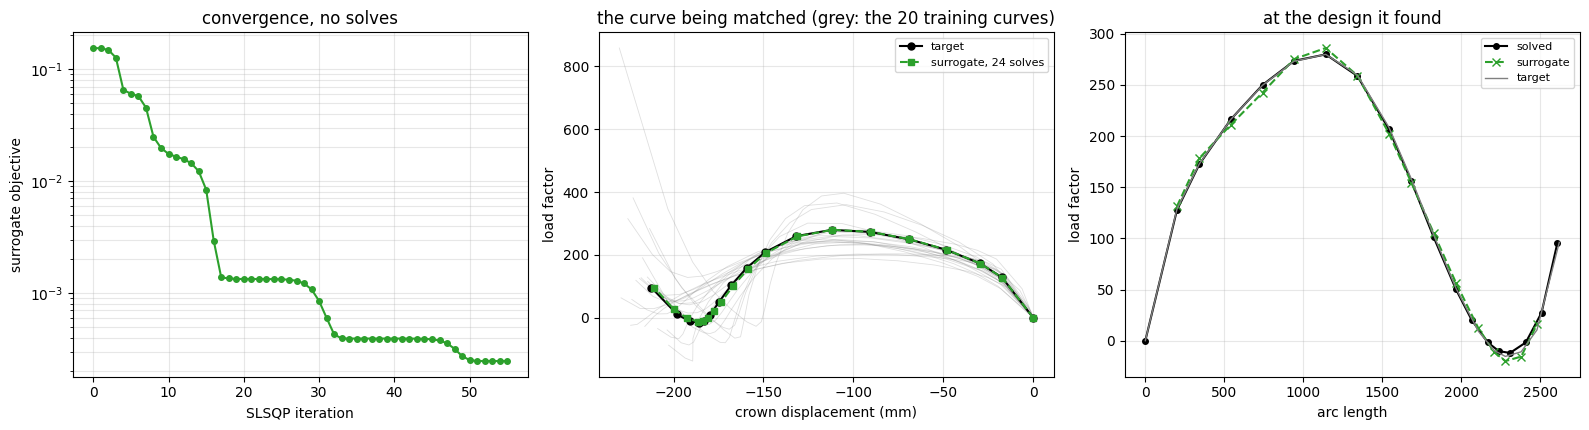

In [10]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.4))

a1.semilogy(np.concatenate(([Surrogate.Value(Start)], History)), 'o-', ms=4, color='tab:green')
a1.set(xlabel='SLSQP iteration', ylabel='surrogate objective', title='convergence, no solves')
a1.grid(alpha=0.3, which='both')

for _, P in Paths:
    a2.plot(P['u'], P['lam'], '-', lw=0.6, alpha=0.25, color='grey')
a2.plot(MSE.uT, MSE.lamT, 'o-', color='k', ms=5, lw=1.5, label='target')
a2.plot(FoundPath['u'], FoundPath['lam'], 's--', color='tab:green', ms=4,
        label=f'surrogate, {Solves + 2} solves')
a2.set(xlabel='crown displacement (mm)', ylabel='load factor',
       title='the curve being matched (grey: the 20 training curves)')
a2.legend(fontsize=8)
a2.grid(alpha=0.3)

a3.plot(FoundPath['s'], FoundPath['lam'], 'o-', color='k', ms=4, label='solved')
a3.plot(Surrogate.At, LamModel.Predict(Result.x[None, :], Surrogate.At), 'x--',
        color='tab:green', ms=6, label='surrogate')
a3.plot(MSE.sT, MSE.lamT, '-', color='grey', lw=1, label='target')
a3.set(xlabel='arc length', ylabel='load factor', title='at the design it found')
a3.legend(fontsize=8)
a3.grid(alpha=0.3)
plt.tight_layout()

print('the right panel is the diagnostic: where predicted and solved disagree, the fit is the')
print('limiting factor rather than the optimiser.')

## What this shows

- **A better match than either solver-based optimiser, for fewer solves.** Read the table on
  objective B, which is what is being minimised. Every solve is around a minute of finite
  element work carrying sensitivities; the 200 SLSQP runs cost none of them.
- **The discontinuity is gone.** The gradient agrees with central differences to nine figures
  with no arc-step count to flag. SLSQP terminates successfully rather than stopping on a jump,
  all 200 starts reach the same point, and none finishes on a box bound.
- **Excluding the collapsed curves is what made it work.** With them in, cross-validation error
  is 26% instead of 6% and the fitted objective rates designs above a perfect match. Three
  curves out of twenty decide whether any of this is usable.
- **The floor is still real.** The surrogate rates its own minimum slightly below a perfect
  match, which cannot be true, and that margin is what it can resolve to. It is small enough
  here not to matter, and the verification solve is what settles the question either way.

**Limits.** The fit is blind to the collapsing region it was not shown, so the box bounds are
load-bearing rather than a formality. Everything quoted is one Latin hypercube draw; a different
seed would give different curves and, on the evidence of the unfiltered fit, possibly a very
different answer.

**Next, and deliberately not here:** infill. Solve at the design SLSQP converged to, add that
curve, refit, repeat — one solve per cycle, spent where the optimiser is looking rather than
spread over the box in advance. Having this one-shot number first is what makes it possible to
say what infill bought.